# Install Library

In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install tqdm
%pip install matplotlib
%pip install tensorboard
%pip install gensim
%pip install nltk
%pip install seaborn
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
%pip install torchinfo

# Setup

In [1]:
import pandas as pd
import numpy as np
import torch

import re

In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath(".")
print("Project root:", PROJECT_ROOT)

CSV_DATASET_PATH = os.path.join(PROJECT_ROOT, "Dataset", "5000human_5000machine.csv")
LOGS_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Logs")
MODELS_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models")
CODES_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Codes")

os.makedirs(LOGS_FOLDER_PATH, exist_ok=True)
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

# allow imports from Codes/
sys.path.append(CODES_FOLDER_PATH)

Project root: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2


In [3]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

In [4]:
BATCH_SIZE = 32

PERFORM_HYPERPARAMETER_TUNING = False

# Raw Data

In [5]:
df = pd.read_csv(CSV_DATASET_PATH)
df.head()

,index,text,label,source,text_word_count,label_cat,source_int,processed_text
0,47,All the Love you do not see\n\nOn writing with...,0,medium,236,human,0,love see write heart hope photo joshua coleman...
1,85,"Reading, writing and displaying images\n\nBefo...",0,medium,386,human,0,read write display image anything computer vis...
2,255,Why I Think “Target Audience” Doesn’t Always M...,0,medium,323,human,0,think target audience always matter much first...
3,268,"All sorts of books are published every year, a...",0,medium,176,human,0,sort book publish every year sort bookbuyers l...
4,315,Finding The Right Question Not Answer\n\nWhen ...,0,medium,264,human,0,find right question answer face problem one fi...


In [6]:
df.shape

(10000, 8)

In [7]:
df.dtypes

index               int64
text               object
label               int64
source             object
text_word_count     int64
label_cat          object
source_int          int64
processed_text     object
dtype: object

In [8]:
print(df.isna().sum())

index              0
text               0
label              0
source             0
text_word_count    0
label_cat          0
source_int         0
processed_text     0
dtype: int64


In [9]:
df['label'].value_counts()

label
0    5000
1    5000
Name: count, dtype: int64

# Preprocessing

In [10]:
from tqdm import tqdm
import re

def clean_text(df):
    cleaned = []

    for text in tqdm(df.str.lower(), desc="Cleaning text"):
        text = re.sub(r"\d+", "", text) # remove digit
        text = re.sub(r"[^\w]", " ", text) # replace punctuations to space
        text = re.sub(r"\s+", " ", text) # remove multiple whitespace

        cleaned.append(text.strip())

    return cleaned

df['clean_text'] = clean_text(df['text'])
df.head()

Cleaning text: 100%|██████████| 10000/10000 [00:01<00:00, 8644.85it/s]


,index,text,label,source,text_word_count,label_cat,source_int,processed_text,clean_text
0,47,All the Love you do not see\n\nOn writing with...,0,medium,236,human,0,love see write heart hope photo joshua coleman...,all the love you do not see on writing with he...
1,85,"Reading, writing and displaying images\n\nBefo...",0,medium,386,human,0,read write display image anything computer vis...,reading writing and displaying images before w...
2,255,Why I Think “Target Audience” Doesn’t Always M...,0,medium,323,human,0,think target audience always matter much first...,why i think target audience doesn t always mat...
3,268,"All sorts of books are published every year, a...",0,medium,176,human,0,sort book publish every year sort bookbuyers l...,all sorts of books are published every year an...
4,315,Finding The Right Question Not Answer\n\nWhen ...,0,medium,264,human,0,find right question answer face problem one fi...,finding the right question not answer when fac...


In [11]:
from sklearn.model_selection import train_test_split

# ratio 60:20:20
x_train, x_temp, y_train, y_temp = train_test_split(df['clean_text'], df['label'], test_size=0.4, random_state=RANDOM_SEED, stratify=df['label_cat'])
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

# Convert to numpy arrays
x_train = np.array(x_train)
x_val = np.array(x_val)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print('train_data =', len(x_train))
print('val_data   =', len(x_val))
print('test_data  =', len(x_test))

train_data = 6000
val_data   = 2000
test_data  = 2000


In [12]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    # tokenize, stop word removal, lemmatize
    tokens = word_tokenize(text)

    result = []
    for tok in tokens:
        if tok in stop_words:
            continue
        tok = lemmatizer.lemmatize(tok)
        result.append(tok)

    return result

x_train_tokens = [preprocess_text(text) for text in x_train]
x_val_tokens   = [preprocess_text(text) for text in x_val]
x_test_tokens  = [preprocess_text(text) for text in x_test]

In [13]:
print(x_train_tokens[0])
print(x_train[0])

['globally', 'renowned', 'hotel', 'management', 'company', 'rezidor', 'group', 'engaged', 'operate', 'entire', 'resort', 'responsible', 'ensure', 'efficient', 'operation', 'hotel', 'upon', 'opening', 'several', 'month', 'preparation', 'segment', 'hotel', 'operation', 'including', 'pre', 'opening', 'phase', 'order', 'make', 'sure', 'employee', 'visitor', 'safe', 'major', 'security', 'risk', 'company', 'continue', 'provide', 'secure', 'management', 'service', 'employee', 'successful', 'fiscal', 'year']
the globally renowned hotel management company rezidor group was engaged to operate the entire resort and will be responsible to ensure efficient operation of the hotel upon its opening with several months of preparation in all segments of hotel operation including the pre opening phase in order to make sure that all employees and visitors are safe from a major security risk the company will continue to provide secure management services to employees during our successful fiscal year


In [14]:
from collections import Counter

def build_vocab(tokens, max_vocab=20000, min_freq=2):
    counter = Counter()

    for token in tokens:
        counter.update(token)   

    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2

    for word, freq in counter.most_common(max_vocab):
        if freq < min_freq:
            break
        vocab[word] = idx
        idx += 1

    return vocab

vocab = build_vocab(x_train_tokens, 30000)

vocab_size = len(vocab)
print(vocab_size)

27034


In [15]:
def encode(text, vocab):
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

x_train_seq = [encode(t, vocab) for t in x_train]
x_val_seq   = [encode(t, vocab) for t in x_val]
x_test_seq  = [encode(t, vocab) for t in x_test]

print(x_train_seq[0])

[1, 3840, 6602, 321, 685, 74, 1, 87, 1, 2249, 1, 3340, 1, 565, 3546, 1, 11923, 1, 1064, 1, 957, 1812, 901, 1, 1, 321, 1200, 1, 1441, 1, 272, 1, 1, 3341, 11170, 1, 1, 1, 321, 901, 145, 1, 1376, 1441, 1585, 11170, 134, 1, 10, 162, 1, 1, 1, 1, 1, 1, 1091, 1, 1, 378, 239, 671, 1, 74, 11923, 469, 1, 360, 1455, 685, 1, 1, 1, 1, 1, 774, 4619, 6]


In [16]:
from gensim.models import Word2Vec

embed_dimension = 100

w2v_model = Word2Vec(
    sentences=x_train_tokens,
    vector_size=embed_dimension,
    window=5,
    min_count=2,
    seed=RANDOM_SEED
)

In [17]:
import numpy as np

embedding_matrix = np.zeros((vocab_size, embed_dimension))

for word, idx in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

Min: 1
Max: 2601
Mean: 277.91333333333336
Median: 288.0
Max length (90th percentile): 434


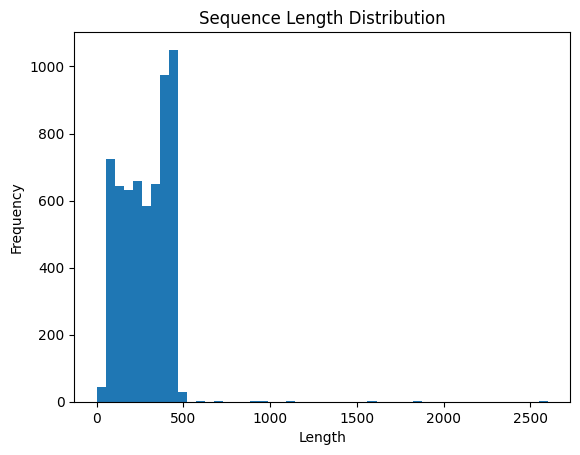

In [18]:
import numpy as np
import matplotlib.pyplot as plt

lengths = [len(seq) for seq in x_train_seq]
max_len = int(np.percentile(lengths, 90))

print("Min:", np.min(lengths))
print("Max:", np.max(lengths))
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("Max length (90th percentile):", max_len)

plt.hist(lengths, bins=50)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [19]:
import torch

def pad(sequences, max_len):
    padded = []

    for seq in sequences:
        seq = torch.tensor(seq, dtype=torch.long)

        # truncate
        seq = seq[:max_len]

        # pad
        if len(seq) < max_len:
            pad_size = max_len - len(seq)
            seq = torch.cat([seq, torch.zeros(pad_size, dtype=torch.long)])

        padded.append(seq)

    return torch.stack(padded)

x_train_encoded = pad(x_train_seq, max_len)
x_val_encoded   = pad(x_val_seq, max_len)
x_test_encoded  = pad(x_test_seq, max_len)

y_train = torch.tensor(y_train)
y_val   = torch.tensor(y_val)
y_test  = torch.tensor(y_test)

# Dataset

In [20]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(TextDataset(x_train_encoded, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(x_val_encoded, y_val), batch_size=BATCH_SIZE)
test_loader  = DataLoader(TextDataset(x_test_encoded, y_test), batch_size=BATCH_SIZE)

In [22]:
import importlib
import Models
import TrainFunctions

importlib.reload(Models)
importlib.reload(TrainFunctions)

<module 'TrainFunctions' from 'c:\\Users\\kevin\\Documents\\Binus\\Semester 8\\Deep Learning Python 3.10\\Deep Learning AoL 2\\Codes\\TrainFunctions.py'>

# Train LSTM

In [202]:
from Models import LSTM
import torch.nn as nn
from TrainFunctions import train_model, log_to_tensorboard

import itertools
from datetime import datetime

if PERFORM_HYPERPARAMETER_TUNING == True:
    # Hyperparameters
    param_grid = {
        "batch_size": [BATCH_SIZE],
        "vocab_size": [vocab_size],
        "max_sequence_length": [max_len],
        "hidden_size": [32, 64, 128],
        "lr": [1e-3, 1e-4, 1e-5],
        "embed_trainable": [True, False],
        "loss_function": ["CrossEntropyLoss"],
        "optimizer": ["Adam"]
    }

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for i, hparams in enumerate(combinations):
        print("Config:", hparams)
        print("====================")

        run_id = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{i}"

        lstm_model = LSTM(
            vocab_size=vocab_size,
            embed_dim=embed_dimension,
            hidden_size=hparams["hidden_size"],
            num_classes=2,
            embed_matrix=embedding_matrix,
            trainable=hparams["embed_trainable"]
        ).to(device)

        loss_function = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            lstm_model.parameters(),
            lr=hparams["lr"]
        )

        best_model_path = os.path.join(MODELS_FOLDER_PATH, f"tuning_lstm/lstm_{run_id}.pt")
        os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

        history, best_val_metrics = train_model(
            model=lstm_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            loss_function=loss_function,
            optimizer=optimizer,
            device=device,
            best_model_path=best_model_path,
            patience=10,
            verbose=False
        )

        log_dir = os.path.join(LOGS_FOLDER_PATH, f"lstm/lstm_{run_id}")
        os.makedirs(os.path.dirname(log_dir), exist_ok=True)

        log_to_tensorboard(log_dir, hparams, history, best_val_metrics)

In [203]:
from Models import LSTM

lstm_model = LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dimension,
    hidden_size=32,
    num_classes=2,
    embed_matrix=embedding_matrix,
    trainable=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = lstm_model.to(device)

In [204]:
from torchinfo import summary

summary(
    lstm_model,
    input_size=(BATCH_SIZE, max_len),
    dtypes=[torch.long]
)

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [32, 2]                   --
├─Embedding: 1-1                         [32, 434, 100]            (2,703,400)
├─LSTM: 1-2                              [32, 434, 32]             17,152
├─BatchNorm1d: 1-3                       [32, 32]                  64
├─Linear: 1-4                            [32, 2]                   66
Total params: 2,720,682
Trainable params: 17,282
Non-trainable params: 2,703,400
Total mult-adds (M): 324.72
Input size (MB): 0.11
Forward/backward pass size (MB): 14.67
Params size (MB): 10.88
Estimated Total Size (MB): 25.67

In [205]:
import torch.nn as nn
from TrainFunctions import train_model

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

best_model_path = os.path.join(MODELS_FOLDER_PATH, "lstm.pt")

history, _ = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    loss_function= loss_function,
    optimizer=optimizer,
    device=device,
    best_model_path=best_model_path,
    patience=10
)


Epoch [1/100]


Train Loss: 0.6838 | Train Acc: 0.5445
Val   Loss: 0.6732 | Val   Acc: 0.5670
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\lstm.pt

Epoch [2/100]


Train Loss: 0.6597 | Train Acc: 0.5845
Val   Loss: 0.6667 | Val   Acc: 0.5935
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\lstm.pt

Epoch [3/100]


Train Loss: 0.6223 | Train Acc: 0.6293
Val   Loss: 0.6015 | Val   Acc: 0.7340
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\lstm.pt

Epoch [4/100]


Train Loss: 0.6471 | Train Acc: 0.6135
Val   Loss: 0.6585 | Val   Acc: 0.5930
Patience: 1/10

Epoch [5/100]


...

Train Loss: 0.1553 | Train Acc: 0.9403
Val   Loss: 0.4425 | Val   Acc: 0.8390
Patience: 6/10

Epoch [55/100]


Train Loss: 0.1435 | Train Acc: 0.9445
Val   Loss: 0.2649 | Val   Acc: 0.9015
Patience: 7/10

Epoch [56/100]


Train Loss: 0.1647 | Train Acc: 0.9368
Val   Loss: 0.2409 | Val   Acc: 0.9080
Patience: 8/10

Epoch [57/100]


Train Loss: 0.1332 | Train Acc: 0.9493
Val   Loss: 0.2971 | Val   Acc: 0.8960
Patience: 9/10

Epoch [58/100]


Train Loss: 0.1470 | Train Acc: 0.9427
Val   Loss: 0.2707 | Val   Acc: 0.8985
Patience: 10/10
Early stopping triggered.


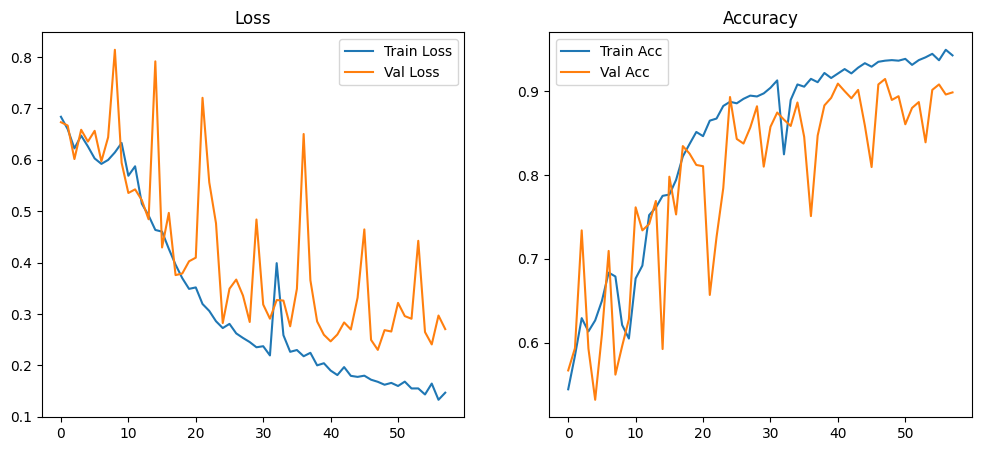

In [206]:
from TrainFunctions import plot_history

plot_history(history)

# Train CNN LSTM

In [207]:
from Models import Parallel_CNN_LSTM
import torch.nn as nn
from TrainFunctions import train_model, log_to_tensorboard

import itertools
from datetime import datetime

if PERFORM_HYPERPARAMETER_TUNING == True:
    # Hyperparameters
    param_grid = {
        "batch_size": [BATCH_SIZE],
        "vocab_size": [vocab_size],
        "max_sequence_length": [max_len],
        "hidden_size": [32, 64, 128],
        "num_filters": [64],
        "lr": [1e-3, 1e-4, 1e-5],
        "embed_trainable": [True, False],
        "loss_function": ["CrossEntropyLoss"],
        "optimizer": ["Adam"]
    }

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for i, hparams in enumerate(combinations):
        print("Config:", hparams)
        print("====================")

        run_id = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{i}"

        parallel_model = Parallel_CNN_LSTM(
            vocab_size=vocab_size,
            embed_dim=embed_dimension,
            hidden_size=hparams["hidden_size"],
            num_filters=hparams["num_filters"],
            num_classes=2,
            embed_matrix=embedding_matrix,
            trainable=hparams["embed_trainable"]
        ).to(device)

        loss_function = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            parallel_model.parameters(),
            lr=hparams["lr"]
        )

        best_model_path = os.path.join(MODELS_FOLDER_PATH, f"tuning_parallelModel/parallelModel_{run_id}.pt")
        os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

        history, best_val_metrics = train_model(
            model=parallel_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            loss_function=loss_function,
            optimizer=optimizer,
            device=device,
            best_model_path=best_model_path,
            patience=10,
            verbose=False
        )

        log_dir = os.path.join(LOGS_FOLDER_PATH, f"parallelModel/parallelModel_{run_id}")
        os.makedirs(os.path.dirname(log_dir), exist_ok=True)

        log_to_tensorboard(log_dir, hparams, history, best_val_metrics)

In [208]:
from Models import Parallel_CNN_LSTM

parallel_model = Parallel_CNN_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dimension,
    hidden_size=128,
    num_classes=2,
    embed_matrix=embedding_matrix,
    trainable=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parallel_model = parallel_model.to(device)

In [209]:
from torchinfo import summary

summary(
    parallel_model,
    input_size=(BATCH_SIZE, max_len),
    dtypes=[torch.long]
)

Layer (type:depth-idx)                   Output Shape              Param #
Parallel_CNN_LSTM                        [32, 2]                   --
├─Embedding: 1-1                         [32, 434, 100]            2,703,400
├─LSTM: 1-2                              [32, 434, 128]            117,760
├─BatchNorm1d: 1-3                       [32, 128]                 256
├─ModuleList: 1-4                        --                        --
│    └─Conv1d: 2-1                       [32, 64, 433]             12,864
│    └─Conv1d: 2-2                       [32, 64, 432]             19,264
│    └─Conv1d: 2-3                       [32, 64, 430]             32,064
├─BatchNorm1d: 1-5                       [32, 192]                 384
├─Linear: 1-6                            [32, 2]                   642
Total params: 2,886,634
Trainable params: 2,886,634
Non-trainable params: 0
Total mult-adds (G): 2.61
Input size (MB): 0.11
Forward/backward pass size (MB): 46.63
Params size (MB): 11.55
Estimated T

In [210]:
import torch.nn as nn
from TrainFunctions import train_model

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(parallel_model.parameters(), lr=1e-5)

best_model_path = os.path.join(MODELS_FOLDER_PATH, "parallel.pt")

history, _ = train_model(
    model=parallel_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=200,
    loss_function= loss_function,
    optimizer=optimizer,
    device=device,
    best_model_path=best_model_path,
    patience=10
)


Epoch [1/200]


Train Loss: 0.6403 | Train Acc: 0.6237
Val   Loss: 0.5642 | Val   Acc: 0.7045
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\parallel.pt

Epoch [2/200]


Train Loss: 0.5418 | Train Acc: 0.7140
Val   Loss: 0.5252 | Val   Acc: 0.7390
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\parallel.pt

Epoch [3/200]


Train Loss: 0.5111 | Train Acc: 0.7452
Val   Loss: 0.5031 | Val   Acc: 0.7570
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\parallel.pt

Epoch [4/200]


Train Loss: 0.4901 | Train Acc: 0.7510
Val   Loss: 0.4858 | Val   Acc: 0.7695
Best model saved to: c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Models\parallel.pt

Epoch [5/200]


...

Train Loss: 0.0297 | Train Acc: 0.9933
Val   Loss: 0.2727 | Val   Acc: 0.9015
Patience: 6/10

Epoch [94/200]


Train Loss: 0.0346 | Train Acc: 0.9910
Val   Loss: 0.2272 | Val   Acc: 0.9065
Patience: 7/10

Epoch [95/200]


Train Loss: 0.0267 | Train Acc: 0.9955
Val   Loss: 0.2011 | Val   Acc: 0.9300
Patience: 8/10

Epoch [96/200]


Train Loss: 0.0265 | Train Acc: 0.9950
Val   Loss: 0.2400 | Val   Acc: 0.9185
Patience: 9/10

Epoch [97/200]


Train Loss: 0.0250 | Train Acc: 0.9958
Val   Loss: 0.5239 | Val   Acc: 0.8325
Patience: 10/10
Early stopping triggered.


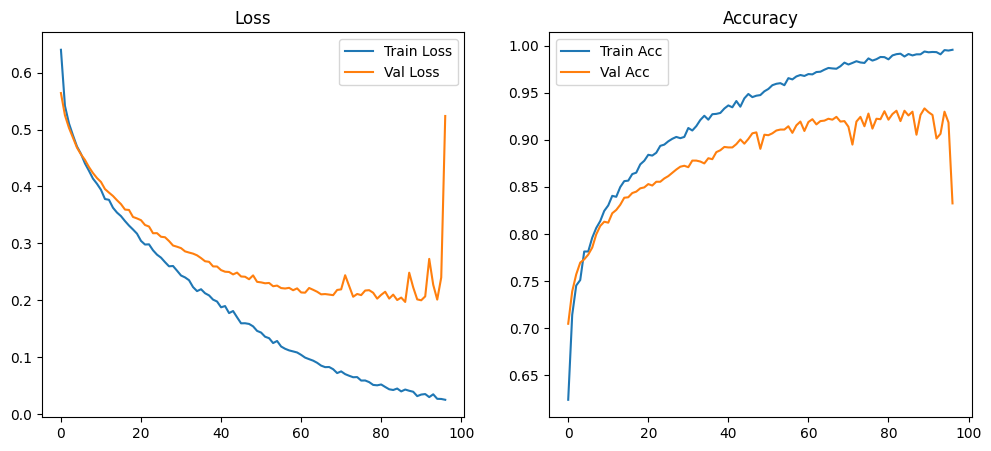

In [226]:
from TrainFunctions import plot_history

plot_history(history)

# Evaluate

In [25]:
from TrainFunctions import evaluate_model, plot_precision_recall_curve

In [228]:
from Models import LSTM

lstm_model = LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dimension,
    hidden_size=32,
    num_classes=2,
    embed_matrix=embedding_matrix,
    trainable=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = lstm_model.to(device)

LSTM_model_path = os.path.join(MODELS_FOLDER_PATH, "lstm.pt")
checkpoint = torch.load(LSTM_model_path, map_location=device)
lstm_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Codes\TrainFunctions.py:233: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


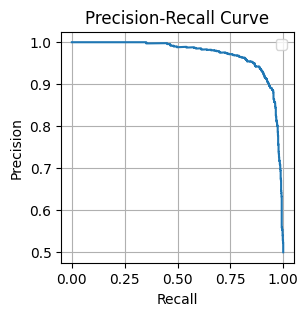

Default F1 (0.5 threshold): 0.9156

Best F1: 0.9176
Best Threshold: 0.3914


In [229]:
lstm_best_threshold = plot_precision_recall_curve(lstm_model, val_loader, device)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9062    0.8500    0.8772      1000
           1     0.8588    0.9120    0.8846      1000

    accuracy                         0.8810      2000
   macro avg     0.8825    0.8810    0.8809      2000
weighted avg     0.8825    0.8810    0.8809      2000


OVERALL
Accuracy : 0.8810
Precision: 0.8588
Recall   : 0.9120
F1-score : 0.8846

CONFUSION MATRIX


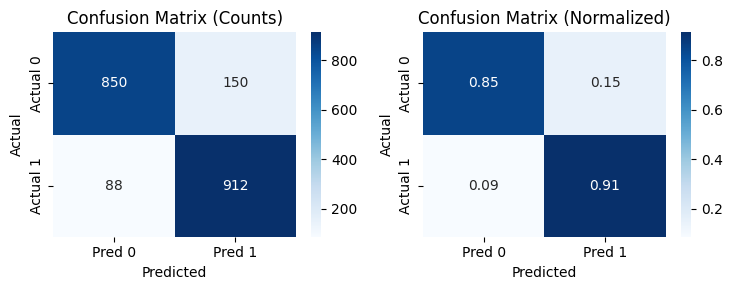

In [230]:
evaluate_model(lstm_model, test_loader, device, lstm_best_threshold)

In [23]:
from Models import Parallel_CNN_LSTM

parallel_model = Parallel_CNN_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dimension,
    hidden_size=128,
    num_classes=2,
    embed_matrix=embedding_matrix,
    trainable=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parallel_model = parallel_model.to(device)

Parallel_model_path = os.path.join(MODELS_FOLDER_PATH, "parallel.pt")
checkpoint = torch.load(Parallel_model_path, map_location=device)
parallel_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

c:\Users\kevin\Documents\Binus\Semester 8\Deep Learning Python 3.10\Deep Learning AoL 2\Codes\TrainFunctions.py:233: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


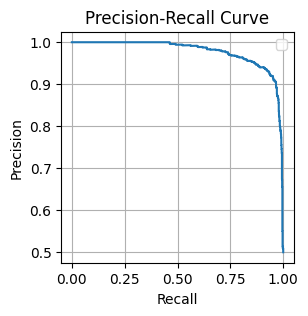

Default F1 (0.5 threshold): 0.9305

Best F1: 0.9346
Best Threshold: 0.4499


In [232]:
parallel_best_threshold = plot_precision_recall_curve(parallel_model, val_loader, device)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9182    0.8980    0.9080      1000
           1     0.9002    0.9200    0.9100      1000

    accuracy                         0.9090      2000
   macro avg     0.9092    0.9090    0.9090      2000
weighted avg     0.9092    0.9090    0.9090      2000


OVERALL
Accuracy : 0.9090
Precision: 0.9002
Recall   : 0.9200
F1-score : 0.9100

CONFUSION MATRIX


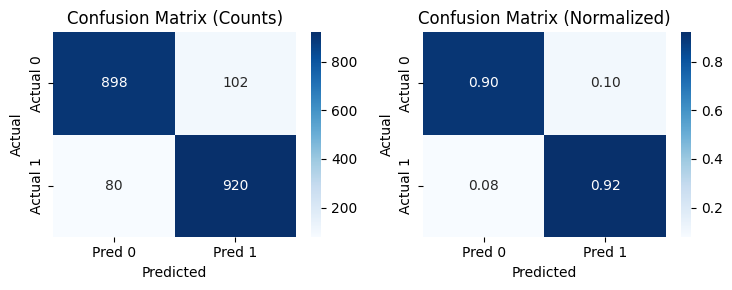

In [233]:
evaluate_model(parallel_model, test_loader, device, parallel_best_threshold)